### DRIVER MONITORING SYSTEM — Intelligent Transportation Project

**Objective:** Build a system that analyzes driver alert data from vehicles to understand driving behavior, identify risky patterns, and classify drivers into safety levels. This falls under the broader domain of Intelligent Transportation Systems (ITS) — where data, sensors, and AI combine to make transport safer and more efficient.

# Phase 1 — Introduction
Modern vehicles are equipped with sensors that monitor lane keeping, distance from other vehicles, and speed. When a driver performs an unsafe action — like tailgating, drifting out of a lane, or overspeeding — the system triggers an **alert**.

These alerts reflect how attentively and safely someone drives.
By analyzing them, we can:
- Detect *risky driving habits*.
- Spot *fatigue or distraction patterns*.
- Identify *accident-prone roads or timings*.

**Our datasets include:**
1. **DMS_Nov23_Hyd_kd.csv** – Alerts collected in November 2023.
2. **DMS_Jan24_Hyd_kd.csv** – Alerts collected in January 2024.
3. **Driver Data_Age_Exp.xlsx** – Driver demographic info: age, education, experience.

We'll combine these to build a **Driver Monitoring System** capable of scoring and classifying drivers as *Highly Unsafe, Unsafe, Moderate Safe,* or *Low Risk.*

# Phase 2 — Importing Libraries

We'll start by importing essential Python libraries for analysis and visualization. Each one has a purpose:
1. **pandas** → Handle structured datasets.
2. **numpy** → Perform mathematical operations.
3. **matplotlib & seaborn** → Create charts and visualizations.
4. **folium** → Plot geographic data (GPS coordinates) on interactive maps.
5. **sklearn** → For data normalization and optional clustering.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.preprocessing import MinMaxScaler

In [17]:
# Set visual style for plots
sns.set(style='whitegrid')


print("Libraries imported successfully!")

Libraries imported successfully!


# Phase 3 — Loading Datasets

We’ll now load the three provided datasets. Before diving into analysis, it’s crucial to **inspect their structure** — see how many rows, what columns they have, and whether they contain missing values.

This helps confirm that the data is read correctly and reveals any immediate cleaning needs.

**Steps:**
1. Load CSV and Excel files using `pandas`.
2. Display their shapes (rows × columns).
3. Show a preview of the first few rows to understand the structure.

In [18]:
# File paths (adjust if needed)
JAN_PATH = 'DMS_Jan24_Hyd_kd.csv'
NOV_PATH = 'DMS_Nov23_Hyd_kd.csv'
DRIVER_META_PATH = 'Driver Data_Age_Exp.xlsx'


# Load data
jan = pd.read_csv(JAN_PATH)
nov = pd.read_csv(NOV_PATH)
drivers = pd.read_excel(DRIVER_META_PATH)


# Print dataset dimensions
print(f"January alerts: {jan.shape}")
print(f"November alerts: {nov.shape}")
print(f"Driver metadata: {drivers.shape}\n")

January alerts: (26750, 10)
November alerts: (47991, 10)
Driver metadata: (202, 26)



In [19]:
print(jan.head(3).to_string(index=False))

alertType vehicleNum       date     time        startTime          endTime    GPSlat    GPSlng  Speed  Time__seconds
      hmw  TS08Z0204 01-01-2024 19:28:18 01-01-2024 19:28 01-01-2024 19:28 17.393422 78.476228     26          70098
      pcw  TS08Z0204 03-01-2024 11:41:37 03-01-2024 11:41 03-01-2024 11:41 17.386512 78.478457     47          42097
      hmw  TS08Z0204 03-01-2024 11:42:30 03-01-2024 11:42 03-01-2024 11:42 17.385413 78.481938     27          42150


In [20]:
print(nov.head(3).to_string(index=False))

alertType vehicleNum       date     time        startTime          endTime    GPSlat    GPSlng  Speed  Time__seconds
      ldw ITS08Z0251 01-11-2023 03:40:22 01-11-2023 03:40 01-11-2023 03:40 17.333133 78.588772     66          13222
      ldw ITS08Z0251 01-11-2023 03:49:56 01-11-2023 03:49 01-11-2023 03:49 17.317270 78.658990     63          13796
      ldw ITS08Z0251 01-11-2023 03:50:06 01-11-2023 03:50 01-11-2023 03:50 17.317388 78.660553     60          13806


In [21]:
print(drivers.head(3).to_string(index=False))

      ID          Name          Name with ID  Age  What will you do if you receive alert while driving   Educational level  Total driving experience (Years)  Unnamed: 7 Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15 Unnamed: 16 Unnamed: 17  Unnamed: 18 Unnamed: 19 Unnamed: 20 Unnamed: 21  Unnamed: 22 Unnamed: 23 Unnamed: 24 Unnamed: 25
 11357.0    k.b.ramaya       11357k.b.ramaya   54                                                  1.0                 NaN                                35         NaN        NaN         NaN          NaN          NaN         NaN         NaN         NaN         NaN         NaN         NaN          NaN         NaN         NaN         NaN          NaN         NaN         NaN         NaN
 27961.0       R.B.rao          27961R.B.rao   33                                                  1.0                 1.0                                 5         NaN        NaN         NaN          NaN          NaN       

# Phase 4 — Data Cleaning and Preparation

Raw data often contains inconsistencies such as missing values, redundant columns, or mismatched formats. We’ll clean the datasets so that they can be merged and analyzed uniformly.

**Goals:**
1. Standardize column names (lowercase, remove spaces).
2. Combine `date` and `time` into a single `datetime` column.
3. Remove empty or irrelevant columns.
4. Handle missing GPS or Speed values.
5. Merge November and January data.

In [22]:
# 1️- Normalize column names for uniformity
def normalize_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    return df


jan = normalize_cols(jan)
nov = normalize_cols(nov)
drivers = normalize_cols(drivers)


# Drop unnamed or empty columns from driver data
unnamed_cols = [c for c in drivers.columns if c.startswith('unnamed')]
if unnamed_cols:
    drivers.drop(columns=unnamed_cols, inplace=True)


print("Cleaned column names:")
print("January:", jan.columns.tolist())
print("November:", nov.columns.tolist())
print("Drivers:", drivers.columns.tolist(), "\n")

Cleaned column names:
January: ['alerttype', 'vehiclenum', 'date', 'time', 'starttime', 'endtime', 'gpslat', 'gpslng', 'speed', 'time__seconds']
November: ['alerttype', 'vehiclenum', 'date', 'time', 'starttime', 'endtime', 'gpslat', 'gpslng', 'speed', 'time__seconds']
Drivers: ['id', 'name', 'name_with_id', 'age', 'what_will_you_do_if_you_receive_alert_while_driving', 'educational_level', 'total_driving_experience_(years)'] 



In [23]:
# 2️- Combine date and time columns into a single datetime column
def create_datetime(df, date_col='date', time_col='time', new_col='datetime'):
    df = df.copy()
    df[new_col] = pd.to_datetime(df[date_col].astype(str) + ' ' + df[time_col].astype(str), errors='coerce')
    return df


jan = create_datetime(jan)
nov = create_datetime(nov)


# Drop rows without GPS data
for df, name in [(jan, 'January'), (nov, 'November')]:
    before = df.shape[0]
    df.dropna(subset=['gpslat', 'gpslng'], inplace=True)
    after = df.shape[0]
    print(f"{name}: dropped {before-after} rows missing GPS coordinates.")

January: dropped 0 rows missing GPS coordinates.
November: dropped 0 rows missing GPS coordinates.


In [24]:
# 3️- Standardize alert type text
for df in [jan, nov]:
    df['alerttype'] = df['alerttype'].astype(str).str.strip().str.lower()

In [25]:
# 4️ Combine both months into one dataset
jan['source'] = 'jan24'
nov['source'] = 'nov23'
alerts = pd.concat([jan, nov], ignore_index=True)

print("Combined dataset shape:", alerts.shape)

Combined dataset shape: (74741, 12)


In [26]:
# 5️- Ensure numeric data types
alerts['speed'] = pd.to_numeric(alerts['speed'], errors='coerce')


print("\nFinal columns:")
print(alerts.columns.tolist())


Final columns:
['alerttype', 'vehiclenum', 'date', 'time', 'starttime', 'endtime', 'gpslat', 'gpslng', 'speed', 'time__seconds', 'datetime', 'source']


In [27]:
alerts.to_csv("alerts_cleaned.csv", index=False)

Phase 5 — Exploratory Data Analysis (EDA)

With clean data, we now explore it to discover patterns and trends. This helps us understand how drivers behave and when most alerts occur.

# Goals:
 - Examine the most common alert types.
 - Identify which vehicles trigger the most alerts.
 - Analyze alerts by time of day to detect fatigue or traffic patterns.

Top alert types:
 alerttype
ldw               59104
hmw                7462
dms_distracted     5627
dms_noseatbelt     1327
fcw                 388
Name: count, dtype: int64


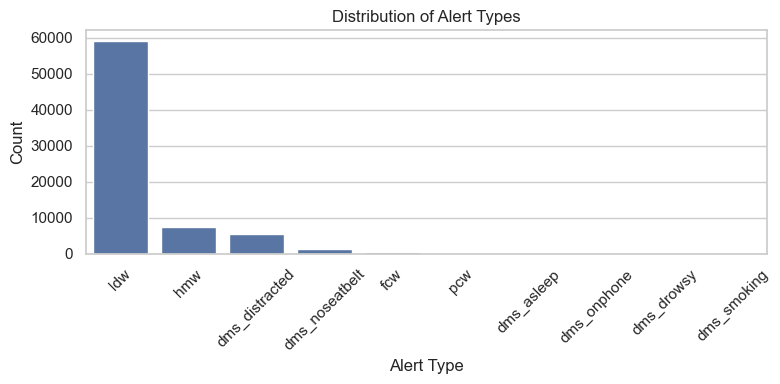

In [25]:
# Alert Type Distribution
top_alerts = alerts['alerttype'].value_counts()
print("Top alert types:\n", top_alerts.head())


plt.figure(figsize=(8,4))
sns.countplot(data=alerts, x='alerttype', order=alerts['alerttype'].value_counts().index)
plt.title('Distribution of Alert Types')
plt.xlabel('Alert Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 4 vehicles by number of alerts:
 vehiclenum
TS09Z7674     34586
TS08Z0204     24726
TS15Z0171     10510
ITS08Z0251     4919
Name: count, dtype: int64


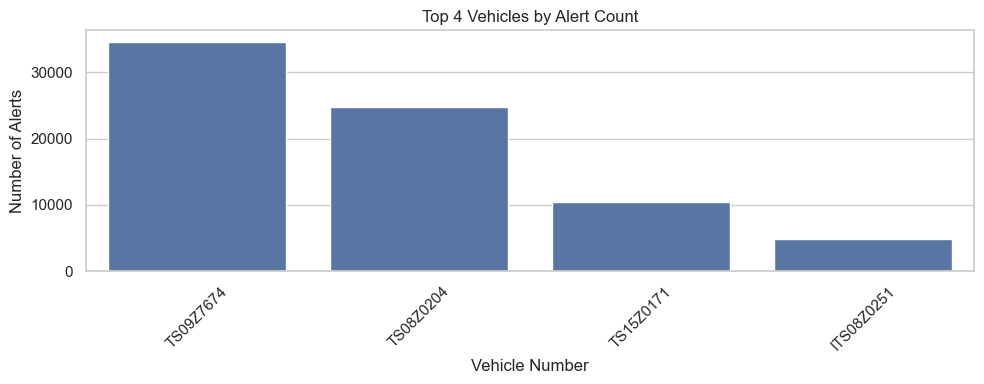

In [26]:
# Alerts per Vehicle
top_vehicles = alerts['vehiclenum'].value_counts().head(4)
print("Top 4 vehicles by number of alerts:\n", top_vehicles)


plt.figure(figsize=(10,4))
sns.barplot(x=top_vehicles.index, y=top_vehicles.values)
plt.title('Top 4 Vehicles by Alert Count')
plt.xlabel('Vehicle Number')
plt.ylabel('Number of Alerts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Phase 6 — Driver Classification (Unsafe, Moderate, Safe)

Now that we understand alert distributions and vehicle behaviors, we’ll classify drivers into safety categories based on their **risk scores**.

# **Goals:**
- Compute a weighted risk score for each vehicle based on alert severity.
- Normalize the scores between 0–100.
- Classify each driver as **Unsafe**, **Moderate**, or **Safe**.

In [27]:
#1️- Define alert severity weights
weights = {
'ldw': 3, # Lane Departure Warning
'pcw': 5, # Pedestrian Collision Warning
'fcw': 5, # Forward Collision Warning
'hmw': 2, # Headway Monitoring Warning
'overspeed': 2,
'speeding': 2
}


# Assign weights to each alert type
alerts['weight'] = alerts['alerttype'].map(weights).fillna(1)

In [28]:
#2️- Aggregate per vehicle (driver)
vehicle_scores = alerts.groupby('vehiclenum').agg(
total_alerts=('alerttype','count'),
weighted_score=('weight','sum'),
mean_speed=('speed','mean')
).reset_index()

In [29]:
#3- Normalize risk score (0–100)
scaler = MinMaxScaler(feature_range=(0,100))
vehicle_scores['risk_score'] = scaler.fit_transform(vehicle_scores[['weighted_score']])

In [30]:
#4️- Classify drivers


def classify_driver(score):
    if score >= 70:
        return 'Unsafe'
    elif score >= 40:
        return 'Moderate'
    else:
        return 'Safe'


vehicle_scores['risk_category'] = vehicle_scores['risk_score'].apply(classify_driver)

print(vehicle_scores[['vehiclenum','total_alerts','weighted_score','risk_score','risk_category']])

   vehiclenum  total_alerts  weighted_score  risk_score risk_category
0  ITS08Z0251          4919         14418.0    0.000000          Safe
1   TS08Z0204         24726         72145.0   81.134223        Unsafe
2   TS09Z7674         34586         85568.0  100.000000        Unsafe
3   TS15Z0171         10510         30920.0   23.193254          Safe


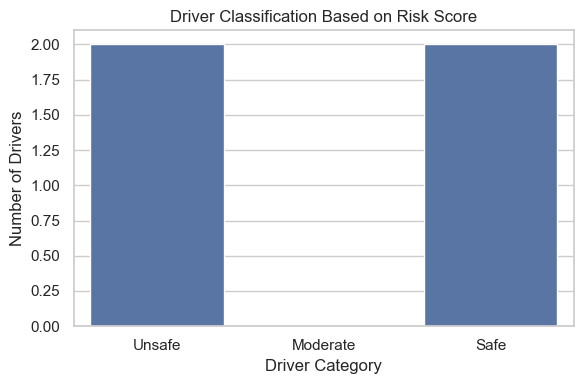

In [31]:
#Visualization — Driver Safety Classification

plt.figure(figsize=(6,4))
sns.countplot(data=vehicle_scores, x='risk_category', order=['Unsafe','Moderate','Safe'])
plt.title('Driver Classification Based on Risk Score')
plt.xlabel('Driver Category')
plt.ylabel('Number of Drivers')
plt.tight_layout()
plt.show()

# Phase 7 — Spatial Visualization and Hotspot Mapping

In this phase, we visualize where alerts occur geographically. GPS coordinates in the dataset let us plot points on a map and identify high-risk zones.

**Goals:**
- Create an interactive map showing where alerts are triggered.
- Highlight dense alert regions (potential accident-prone areas).
- Optionally, overlay driver categories to see which areas correspond to unsafe behavior.

In [32]:
# 1️- Determine map center (average GPS coordinates)
center_lat = alerts['gpslat'].mean()
center_lng = alerts['gpslng'].mean()
print(f"Map center: {center_lat}, {center_lng}")

# 2️- Create base map
m = folium.Map(location=[center_lat, center_lng], zoom_start=11)

Map center: 17.171298730910745, 79.33065329050322


In [33]:
# 3️- Plot a sample of alert points
sample = alerts.sample(min(1000, alerts.shape[0]), random_state=42)
for _, row in sample.iterrows():
    folium.CircleMarker(
    location=[row['gpslat'], row['gpslng']],
    radius=2,
    color='red',
    fill=True,
    fill_opacity=0.6,
    popup=f"{row['alerttype']} | {row['vehiclenum']} | {row['datetime']}"
    ).add_to(m)

In [34]:
# 4️- Add Heatmap layer
heat_data = alerts[['gpslat','gpslng']].dropna().values.tolist()
HeatMap(heat_data[:3000], radius=10, blur=15).add_to(m)


# Save interactive map
m.save('Alert_Hotspot_Map.html')
print("Map saved as 'Alert_Hotspot_Map.html'. Open it in a browser to explore.")

Map saved as 'Alert_Hotspot_Map.html'. Open it in a browser to explore.


In [35]:
alerts['lat_r'] = alerts['gpslat'].round(3)
alerts['lng_r'] = alerts['gpslng'].round(3)


hotspots = alerts.groupby(['lat_r','lng_r']).size().reset_index(name='alert_count').sort_values('alert_count', ascending=False)


print("Top 10 Alert Hotspots:")
print(hotspots.head(10))


# Save hotspots as CSV
hotspots.to_csv('Alert_Hotspots.csv', index=False)
print("Hotspot data saved as 'Alert_Hotspots.csv'")

Top 10 Alert Hotspots:
       lat_r   lng_r  alert_count
807   17.155  79.618          140
11    16.947  80.056          115
1046  17.163  79.547           88
1899  17.276  78.812           88
953   17.160  79.535           86
1418  17.217  79.152           84
1567  17.231  78.980           81
1442  17.226  79.138           80
1884  17.271  78.821           80
12    16.948  80.055           80
Hotspot data saved as 'Alert_Hotspots.csv'


In [36]:
# 1) Prepare hotspot ranks (we already computed `hotspots` in Phase 7)
hotspots = hotspots.copy()
# Add a rank or normalized density measure
hotspots['hotspot_rank'] = hotspots['alert_count'].rank(method='dense', ascending=False)
hotspots['hotspot_density_norm'] = (hotspots['alert_count'] - hotspots['alert_count'].min()) / (hotspots['alert_count'].max() - hotspots['alert_count'].min())

In [37]:
# 2) Merge hotspot info into alerts (on rounded lat/lng)
alerts = alerts.merge(hotspots.rename(columns={'lat_r':'lat_r','lng_r':'lng_r','alert_count':'hotspot_alert_count','hotspot_rank':'hotspot_rank','hotspot_density_norm':'hotspot_density_norm'}), on=['lat_r','lng_r'], how='left')

In [38]:
# 3) Aggregate hotspot exposure per vehicle
vehicle_hotspot = alerts.groupby('vehiclenum').agg(
alerts_in_hotspots=('hotspot_alert_count', lambda x: x.fillna(0).gt(0).sum()), # number of alerts that fall in any hotspot cell
sum_hotspot_density=('hotspot_density_norm', lambda x: x.fillna(0).sum()),
mean_hotspot_density=('hotspot_density_norm', lambda x: x.fillna(0).mean())
).reset_index()

In [39]:
# 4) Merge with vehicle_scores
vehicle_analysis = vehicle_scores.merge(vehicle_hotspot, on='vehiclenum', how='left')
vehicle_analysis[['alerts_in_hotspots','sum_hotspot_density','mean_hotspot_density']] = vehicle_analysis[['alerts_in_hotspots','sum_hotspot_density','mean_hotspot_density']].fillna(0)

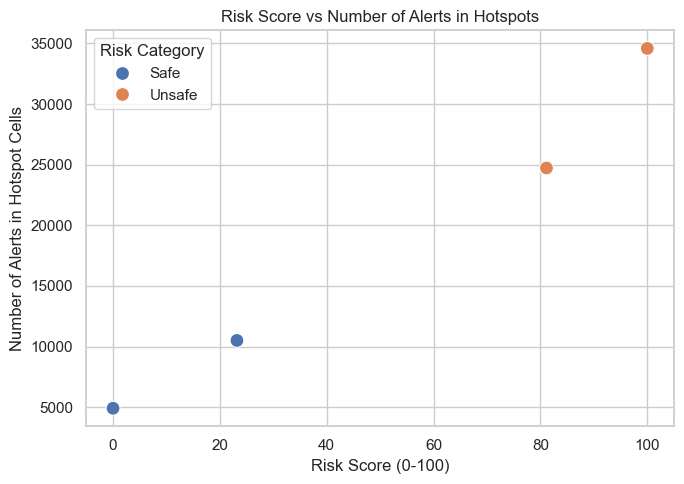

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=vehicle_analysis, x='risk_score', y='alerts_in_hotspots', hue='risk_category', s=100)
plt.title('Risk Score vs Number of Alerts in Hotspots')
plt.xlabel('Risk Score (0-100)')
plt.ylabel('Number of Alerts in Hotspot Cells')
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

Pearson correlation between risk_score and alerts_in_hotspots: 0.990


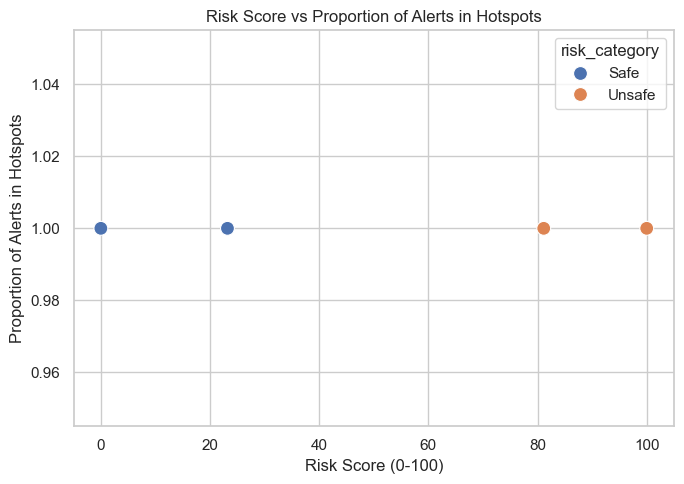

In [41]:
# Correlation
corr = vehicle_analysis['risk_score'].corr(vehicle_analysis['alerts_in_hotspots'])
print(f"Pearson correlation between risk_score and alerts_in_hotspots: {corr:.3f}")


# Another view: normalize alerts_in_hotspots by total_alerts to get proportion
vehicle_analysis['prop_alerts_in_hotspots'] = vehicle_analysis['alerts_in_hotspots'] / vehicle_analysis['total_alerts']


plt.figure(figsize=(7,5))
sns.scatterplot(data=vehicle_analysis, x='risk_score', y='prop_alerts_in_hotspots', hue='risk_category', s=100)
plt.title('Risk Score vs Proportion of Alerts in Hotspots')
plt.xlabel('Risk Score (0-100)')
plt.ylabel('Proportion of Alerts in Hotspots')
plt.tight_layout()
plt.show()

In [42]:
# Show summary table
print('Vehicle analysis (sample):')
print(vehicle_analysis.sort_values('risk_score', ascending=False)[['vehiclenum','total_alerts','risk_score','risk_category','alerts_in_hotspots','prop_alerts_in_hotspots']].to_string(index=False))

Vehicle analysis (sample):
vehiclenum  total_alerts  risk_score risk_category  alerts_in_hotspots  prop_alerts_in_hotspots
 TS09Z7674         34586  100.000000        Unsafe               34586                      1.0
 TS08Z0204         24726   81.134223        Unsafe               24726                      1.0
 TS15Z0171         10510   23.193254          Safe               10510                      1.0
ITS08Z0251          4919    0.000000          Safe                4919                      1.0


In [43]:
# Save analysis
vehicle_analysis.to_csv('vehicle_hotspot_analysis.csv', index=False)
print('Saved vehicle_hotspot_analysis.csv')

Saved vehicle_hotspot_analysis.csv
